In [106]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster
import seaborn as sns

In [32]:
df = pd.read_csv("../data/clean/combined_nps_visitation.csv") #using combined dataset for k-means clustering
print(df.shape)
print(df.describe)
print(df.info())


(7788, 26)
<bound method NDFrame.describe of       Park Name Unit Code      Park Type          Region  Year  Month  \
0     Acadia NP      acad  National Park      Northeast   2015      1   
1     Acadia NP      acad  National Park      Northeast   2015      2   
2     Acadia NP      acad  National Park      Northeast   2015      3   
3     Acadia NP      acad  National Park      Northeast   2015      4   
4     Acadia NP      acad  National Park      Northeast   2015      5   
...         ...       ...            ...             ...   ...    ...   
7783    Zion NP      zion  National Park  Intermountain   2025      8   
7784    Zion NP      zion  National Park  Intermountain   2025      9   
7785    Zion NP      zion  National Park  Intermountain   2025     10   
7786    Zion NP      zion  National Park  Intermountain   2025     11   
7787    Zion NP      zion  National Park  Intermountain   2025     12   

      Recreation Visits  Non Recreation Visits  Recreation Hours  \
0         

In [25]:
#remove 'Park Code', 'State', 'Park'
df.drop(['Park Code', 'State', 'Park'], axis=1, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7788 entries, 0 to 7787
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Park Name                       7788 non-null   object 
 1   Unit Code                       7788 non-null   object 
 2   Park Type                       7788 non-null   object 
 3   Region                          7788 non-null   object 
 4   Year                            7788 non-null   int64  
 5   Month                           7788 non-null   int64  
 6   Recreation Visits               7788 non-null   int64  
 7   Non Recreation Visits           7788 non-null   int64  
 8   Recreation Hours                7788 non-null   int64  
 9   Non Recreation Hours            7788 non-null   int64  
 10  Concessioner Lodging            7788 non-null   int64  
 11  Concessioner Camping            7788 non-null   int64  
 12  Tent Campers                    77

In [67]:
#aggregate by park and take the mean
park_agg = (df.groupby('Park Name').agg({'Recreation Visits': 'mean', 'Non Recreation Visits':'mean', 'Recreation Hours':'mean', 'Non Recreation Hours':'mean', 'Concessioner Lodging':'mean','Concessioner Camping':'mean', 'Tent Campers':'mean', 'RV Campers':'mean', 'Backcountry':'mean','Non Recreation Overnight Stays':'mean','Miscellaneous Overnight Stays':'mean',
'Number of Activities':'mean', 'Entrance Fees':'mean'}).reset_index())
print(park_agg.shape)
park_agg.isnull().sum() #checking for missing vals

(59, 14)


Park Name                         0
Recreation Visits                 0
Non Recreation Visits             0
Recreation Hours                  0
Non Recreation Hours              0
Concessioner Lodging              0
Concessioner Camping              0
Tent Campers                      0
RV Campers                        0
Backcountry                       0
Non Recreation Overnight Stays    0
Miscellaneous Overnight Stays     0
Number of Activities              0
Entrance Fees                     0
dtype: int64

In [ ]:
park_feat = ['Recreation Visits','Non Recreation Visits', 'Recreation Hours', 'Non Recreation Hours','Concessioner Lodging','Concessioner Camping', 'Tent Campers', 'RV Campers', 'Backcountry','Non Recreation Overnight Stays','Miscellaneous Overnight Stays',
'Number of Activities', 'Entrance Fees'] #picking features
park_agg.describe().T #checking to see which values have a lot of 0s and 75% of Non Rec Overnight Stays are 0, so I will remove this
park_feat.remove('Non Recreation Overnight Stays')
x = park_agg[park_feat]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [69]:
park_agg.head()
park_agg.to_csv('../data/clean/park_agg.csv', index=False)

Text(0, 0.5, 'CS')

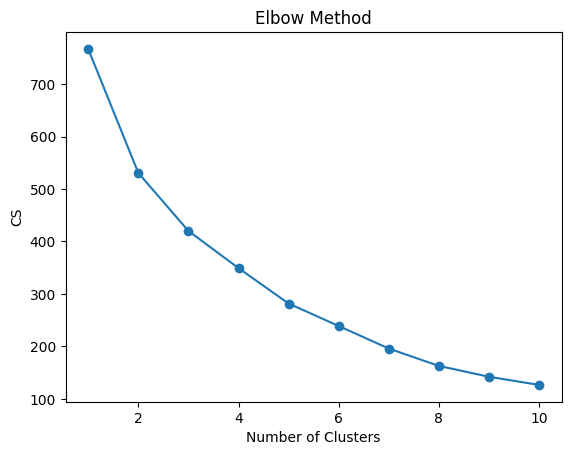

In [57]:
cs=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init ='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1,11),cs,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('CS')

Elbow method says to use 3-4 clusters, but now we are going to determine cluster amounts with silhouette scores.

k=2: 0.641
k=3: 0.621
k=4: 0.201
k=5: 0.278
k=6: 0.225
k=7: 0.314
k=8: 0.257
k=9: 0.253
k=10: 0.216


Text(0, 0.5, 'Silhouette Score')

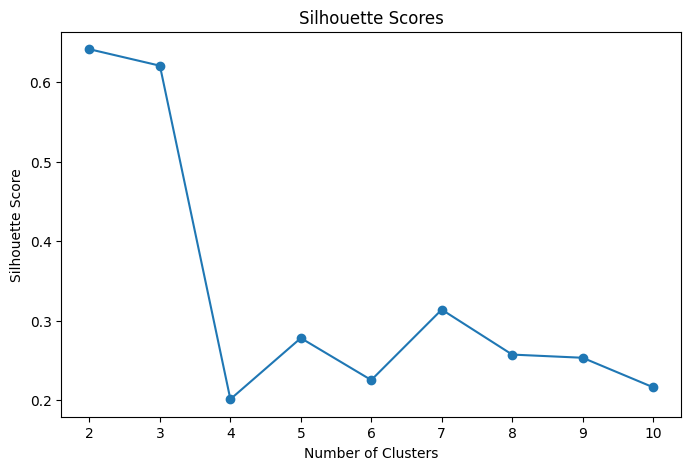

In [56]:
sil_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10,random_state=0)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    sil_scores.append(score)
    print(f'k={k}: {score:.3f}')

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

The silhouette scores tell us that 2-3 clusters is optimal

In [ ]:
#2 clusters 
kmeans2 = KMeans(n_clusters=2,random_state=0,n_init=10)
park_agg['Cluster'] = kmeans2.fit_predict(x_scaled)
print(park_agg[['Park Name', 'Cluster']].sort_values('Cluster'))
park_agg.groupby('Cluster')[park_feat].mean().round(2)

                          Park Name  Cluster
0                         Acadia NP        0
1                         Arches NP        0
2                       Badlands NP        0
3                       Big Bend NP        0
4                       Biscayne NP        0
5   Black Canyon of the Gunnison NP        0
6                   Bryce Canyon NP        0
7                    Canyonlands NP        0
8                   Capitol Reef NP        0
9               Carlsbad Caverns NP        0
10               Channel Islands NP        0
11                      Congaree NP        0
12                   Crater Lake NP        0
13               Cuyahoga Valley NP        0
14                  Death Valley NP        0
15                 Denali NP & PRES        0
16                  Dry Tortugas NP        0
17                    Everglades NP        0
18    Gates of the Arctic NP & PRES        0
19                  Gateway Arch NP        0
20            Glacier Bay NP & PRES        0
21        

,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
Cluster,,,,,,,,,,,,
0,90868.27,17637.85,533729.55,17637.85,1199.67,802.64,2265.97,1419.23,1114.82,595.75,30.45,16.78
1,530174.12,253031.40,6289031.57,253031.40,36641.10,11121.15,15363.48,9983.33,12061.91,1611.53,38.50,26.25


In [ ]:
#3 clusters
kmeans3 = KMeans(n_clusters=3,random_state=0,n_init=10)
park_agg['Cluster'] = kmeans3.fit_predict(x_scaled)
print(park_agg[['Park Name', 'Cluster']].sort_values('Cluster'))
park_agg.groupby('Cluster')[park_feat].mean().round(2)

                          Park Name  Cluster
0                         Acadia NP        0
1                         Arches NP        0
2                       Badlands NP        0
3                       Big Bend NP        0
4                       Biscayne NP        0
5   Black Canyon of the Gunnison NP        0
6                   Bryce Canyon NP        0
7                    Canyonlands NP        0
8                   Capitol Reef NP        0
9               Carlsbad Caverns NP        0
10               Channel Islands NP        0
11                      Congaree NP        0
12                   Crater Lake NP        0
13               Cuyahoga Valley NP        0
14                  Death Valley NP        0
15                 Denali NP & PRES        0
16                  Dry Tortugas NP        0
17                    Everglades NP        0
18    Gates of the Arctic NP & PRES        0
19                  Gateway Arch NP        0
20            Glacier Bay NP & PRES        0
21        

,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
Cluster,,,,,,,,,,,,
0,90868.27,17637.85,533729.55,17637.85,1199.67,802.64,2265.97,1419.23,1114.82,595.75,30.45,16.78
1,369662.42,39524.00,6113899.78,39524.00,48561.28,14828.19,15479.95,9604.40,13503.32,1420.94,39.33,35.00
2,1011709.22,893553.58,6814426.96,893553.58,880.57,0.00,15014.08,11120.12,7737.67,2183.30,36.00,0.00


Basically, my clustering method is just grouping based mainly on the mass amount of visitation. For k=2, the second was grouped based
off of the mass of visitation those parks (Yellowstone, Great Smokey Mountains, Grand Canyon, and Yosemite). A similar thing happened with k=3, except the Great Smokey Mountain was the only park in the third cluster. To test if besides visitation volume, what parks are similar, I am going to remove recreation hours and recreation visits.

k=2: 0.605
k=3: 0.532
k=4: 0.228
k=5: 0.256
k=6: 0.260
k=7: 0.290
k=8: 0.265
k=9: 0.264
k=10: 0.285


Text(0, 0.5, 'Silhouette Score')

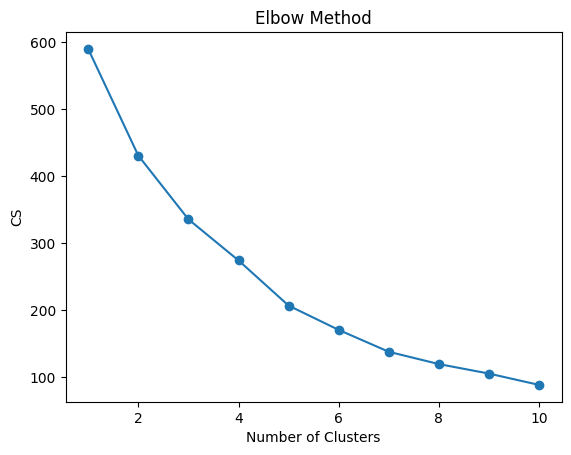

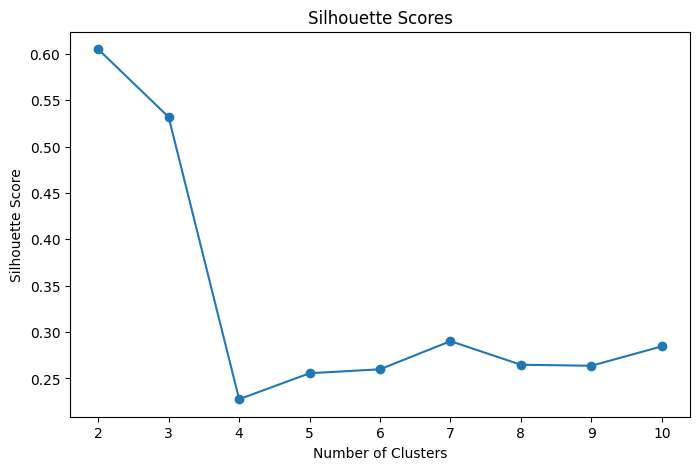

In [91]:
#removing visitation hours and recreation visits
park_feat2 = ['Non Recreation Visits', 'Non Recreation Hours','Concessioner Lodging','Concessioner Camping', 'Tent Campers', 'RV Campers', 'Backcountry','Non Recreation Overnight Stays','Miscellaneous Overnight Stays',
'Number of Activities', 'Entrance Fees'] #picking features
park_agg.describe().T #checking to see which values have a lot of 0s and 75% of Non Rec Overnight Stays are 0, so I will remove this
park_feat2.remove('Non Recreation Overnight Stays')
x = park_agg[park_feat2]
scaler = StandardScaler()
x_scaled2 = scaler.fit_transform(x)

#elbow plot
cs=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init ='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x_scaled2)
    cs.append(kmeans.inertia_)
plt.plot(range(1,11),cs,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('CS')
#elbow around 4 clusters

#silhouette plot
sil_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10,random_state=0)
    labels = kmeans.fit_predict(x_scaled2)
    score = silhouette_score(x_scaled2, labels)
    sil_scores.append(score)
    print(f'k={k}: {score:.3f}')

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

The elbow plot shows that the optimal number of clusters is around 5 clusters because that is where the "bend" of the elbow is. The silhoutte scores tell us otherwise, two clusters have the highest silhouette score of 0.605, meaning that the cluster structure is strong and well defined. 

In [101]:
#2 clusters
kmeans2 = KMeans(n_clusters=2,random_state=0,n_init=10)
park_agg['Cluster'] = kmeans2.fit_predict(x_scaled2)
print(park_agg[['Park Name', 'Cluster']].sort_values('Cluster'))
park_agg.groupby('Cluster')[park_feat2].mean().round(2)

                          Park Name  Cluster
0                         Acadia NP        0
1                         Arches NP        0
2                       Badlands NP        0
3                       Big Bend NP        0
4                       Biscayne NP        0
5   Black Canyon of the Gunnison NP        0
6                   Bryce Canyon NP        0
7                    Canyonlands NP        0
8                   Capitol Reef NP        0
9               Carlsbad Caverns NP        0
10               Channel Islands NP        0
11                      Congaree NP        0
12                   Crater Lake NP        0
13               Cuyahoga Valley NP        0
14                  Death Valley NP        0
15                 Denali NP & PRES        0
16                  Dry Tortugas NP        0
17                    Everglades NP        0
18    Gates of the Arctic NP & PRES        0
19                  Gateway Arch NP        0
20            Glacier Bay NP & PRES        0
21        

,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
Cluster,,,,,,,,,,
0,16715.81,16715.81,1106.73,796.87,2093.67,1320.64,951.28,606.54,30.02,16.54
1,215910.69,215910.69,30556.58,9119.76,14604.82,9335.27,11638.73,1291.87,41.60,27.00


For k=2 clusters, we can see that cluster 0 has a mean of 16715.81 for Non Recreation Visits and Non Recreation Hours. Concessioner lodging has an average of 1106.73 people. The average tent campers for this cluster are ~2093. Average RV campers is ~1320 people and the average amount of backcountry backpackers is ~951. The average amount of miscellaneous stays is ~606. The average number of acitivities is 30 activities and the average entrance fee is $16.54. In cluster 1, there are only five parks: Yosemite, Yellowstone, Olympic, Grand Canyon, and Great Smokey Mountains. For cluster 1, Non Recreation Visits and Non Recreation Hours have a mean of ~215,910. Concessioner lodging has an average of ~30,556 stays. The average tent campers for this cluster are ~14,604. Average RV campers is ~9,335 people and the average amount of backcountry backpackers is ~11,638. The average amount of miscellaneous stays is ~1,291. The average number of acitivities is 41 activities and the average entrance fee is $27. Overall, the clustering divided into two broad groups, standard recreation parks and major destination parks. The biggest differences between the clusters were in lodging, camping, and backcountry use, indicating that overnight recreation opportunities were key factors in the cluster formation.

In [93]:
#3 clusters
kmeans3 = KMeans(n_clusters=3,random_state=0,n_init=10)
park_agg['Cluster'] = kmeans3.fit_predict(x_scaled2)
print(park_agg[['Park Name', 'Cluster']].sort_values('Cluster'))
park_agg.groupby('Cluster')[park_feat2].mean().round(2)

                          Park Name  Cluster
0                         Acadia NP        0
1                         Arches NP        0
2                       Badlands NP        0
3                       Big Bend NP        0
4                       Biscayne NP        0
5   Black Canyon of the Gunnison NP        0
6                   Bryce Canyon NP        0
7                    Canyonlands NP        0
8                   Capitol Reef NP        0
9               Carlsbad Caverns NP        0
10               Channel Islands NP        0
11                      Congaree NP        0
12                   Crater Lake NP        0
13               Cuyahoga Valley NP        0
14                  Death Valley NP        0
15                 Denali NP & PRES        0
16                  Dry Tortugas NP        0
17                    Everglades NP        0
18    Gates of the Arctic NP & PRES        0
19                  Gateway Arch NP        0
20            Glacier Bay NP & PRES        0
27        

,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
Cluster,,,,,,,,,,
0,15144.00,15144.00,714.78,267.60,1702.25,1089.39,864.71,524.32,29.27,15.55
1,45187.06,45187.06,25030.22,10711.78,12036.21,7330.23,8246.40,1469.86,42.86,33.57
2,893553.58,893553.58,880.57,0.00,15014.08,11120.12,7737.67,2183.30,36.00,0.00


For k=3 clusters, we can see that cluster 0 has a mean of 15,144 for Non Recreation Visits and Non Recreation Hours. Concessioner lodging has an average of ~714  people. The average tent campers for this cluster are ~1702. Average RV campers is ~1089 people and the average amount of backcountry backpackers is ~864. The average amount of miscellaneous stays is ~524. The average number of acitivities is 29 activities and the average entrance fee is $15.55. In cluster 1, there are six parks: Grand Teton, Yosemite, Yellowstone, Olympic, Grand Canyon, and Joshua Tree. For cluster 1, Non Recreation Visits and Non Recreation Hours have a mean of ~45,187.06. Concessioner lodging has an average of ~25,030.22 stays. The average tent campers for this cluster are ~10,711. Average RV campers is ~7,330 people and the average amount of backcountry backpackers is ~8,246. The average amount of miscellaneous stays is ~1,469. The average number of acitivities is 42 activities and the average entrance fee is $33.57. In cluster 2, we only have one national park: Great Smoky Mountains. The average number of NOn Recreation Visits is 893,553 and concessioner lodging at 880. Concessioner camping has a mean of 0. There are around an average of 15,014 tent campers and 11,120 RV campers. Backcountry campers have an average of 7,737 campers, which is less than cluster 1. Miscellaenous overnight stays were ~2,183. Finally, Great Smoky Mountains has 36 activities and zero entrance fee. Overall, the clustering divided into two broad groups, standard recreation parks and major destination parks. The biggest differences between the clusters were in lodging, camping, and backcountry use, indicating that overnight recreation opportunities were key factors in the cluster formation.

Overall, the k=3 clustering found three distinct groups of National Parks. Cluster 0 had standard recreation parks with relatively low levels of lodging, camping, and backcountry activity. Cluster 1 contained major destination parks such as Yellowstone, Yosemite, Grand Canyon, Olympic, Grand Teton, and Joshua Tree, which showed higher levels of lodging, camping, recreation opportunities, and entrance fees. Cluster 2 only had Great Smoky Mountains National Park, indicating that its visitation and recreation characteristics are unique enough to distinguish it from all other parks in the dataset. The clustering results suggest that recreation infrastructure, overnight accommodations, camping activity, and visitor demand were the primary factors driving the separation between parks. Additionally, the fact that Great Smoky Mountains formed its own cluster highlights its high levels of visitation and overnight recreation activity compared to the rest of the National Park System.

In [94]:
#4 clusters
kmeans4 = KMeans(n_clusters=4,random_state=0,n_init=10)
park_agg['Cluster'] = kmeans4.fit_predict(x_scaled2)
print(park_agg[['Park Name', 'Cluster']].sort_values('Cluster'))
park_agg.groupby('Cluster')[park_feat2].mean().round(2)

                          Park Name  Cluster
4                       Biscayne NP        0
11                      Congaree NP        0
10               Channel Islands NP        0
15                 Denali NP & PRES        0
13               Cuyahoga Valley NP        0
9               Carlsbad Caverns NP        0
18    Gates of the Arctic NP & PRES        0
16                  Dry Tortugas NP        0
24                   Great Basin NP        0
27           Guadalupe Mountains NP        0
30                   Hot Springs NP        0
28                     Haleakala NP        0
20            Glacier Bay NP & PRES        0
19                  Gateway Arch NP        0
34                 Katmai NP & PRES        0
32                   Isle Royale NP        0
43                North Cascades NP        0
42        New River Gorge NP & PRES        0
48                       Saguaro NP        0
51                Virgin Islands NP        0
54                     Wind Cave NP        0
55     Wra

,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
Cluster,,,,,,,,,,
0,17623.99,17623.99,178.09,73.57,399.13,248.17,622.91,454.49,27.43,5.07
1,39524.00,39524.00,48561.28,14828.19,15479.95,9604.40,13503.32,1420.94,39.33,35.00
2,893553.58,893553.58,880.57,0.00,15014.08,11120.12,7737.67,2183.30,36.00,0.00
3,17652.22,17652.22,2259.08,1558.72,4201.95,2633.65,1624.96,742.25,33.59,28.93


For the k=4 clustering solution, Cluster 0 had a mean of 17,623.99 for Non Recreation Visits and Non Recreation Hours. Concessioner lodging averaged approximately 178 stays, while concessioner camping averaged 74 stays. Tent campers averaged 399 visitors, RV campers averaged 248 visitors, and backcountry use averaged 623 visitors. Parks in this cluster also had the lowest average entrance fee at $5.07 and offered an average of 27 activities. These results suggest that Cluster 0 represents lower-use parks with limited recreation infrastructure and overnight visitation.
Cluster 1 contained Yosemite, Yellowstone, and Grand Canyon. This cluster had a mean of 39,524 for Non Recreation Visits and Non Recreation Hours. Concessioner lodging averaged 48,561 stays, concessioner camping averaged 14,828 stays, tent campers averaged 15,480 visitors, and RV campers averaged 9,604 visitors. Backcountry use averaged 13,503 visitors, the highest among all clusters. Parks in this cluster offered an average of 39 activities and had the highest average entrance fee at $35. These results indicate that Cluster 1 contains the premier destination parks with extensive recreation opportunities and visitor infrastructure.
Cluster 2 consisted solely of Great Smoky Mountains National Park. This cluster had exceptionally high Non Recreation Visits and Non Recreation Hours, averaging 893,554. Tent campers averaged 15,014 visitors, RV campers averaged 11,120 visitors, and miscellaneous overnight stays averaged 2,183. However, concessioner lodging averaged only 881 stays, concessioner camping averaged 0, and the entrance fee was $0. The unique combination of extremely high visitation and recreation activity caused Great Smoky Mountains to form its own cluster.
Cluster 3 included parks such as Acadia, Arches, Glacier, Grand Teton, Olympic, Rocky Mountain, and Zion. This cluster had a mean of 17,652 for Non Recreation Visits and Non Recreation Hours. Concessioner lodging averaged 2,259 stays, concessioner camping averaged 1,559 stays, tent campers averaged 4,202 visitors, and RV campers averaged 2,634 visitors. Backcountry use averaged 1,625 visitors, parks offered an average of 34 activities, and entrance fees averaged $28.93. These values indicate that Cluster 3 represents popular recreation-oriented parks that experience higher camping and recreation activity than Cluster 0 but are smaller in scale than the destination parks in Cluster 1.
Overall, the k=4 clustering solution revealed four distinct groups of National Parks: lower-use parks, premier destination parks, the uniquely high-use Great Smoky Mountains National Park, and popular recreation-oriented parks. The largest differences between the clusters were observed in lodging, camping activity, backcountry use, and entrance fees, suggesting that recreation infrastructure and overnight recreation opportunities were major factors driving cluster formation.


**Cosine Similarity**

Text(0, 0.5, 'Distance')

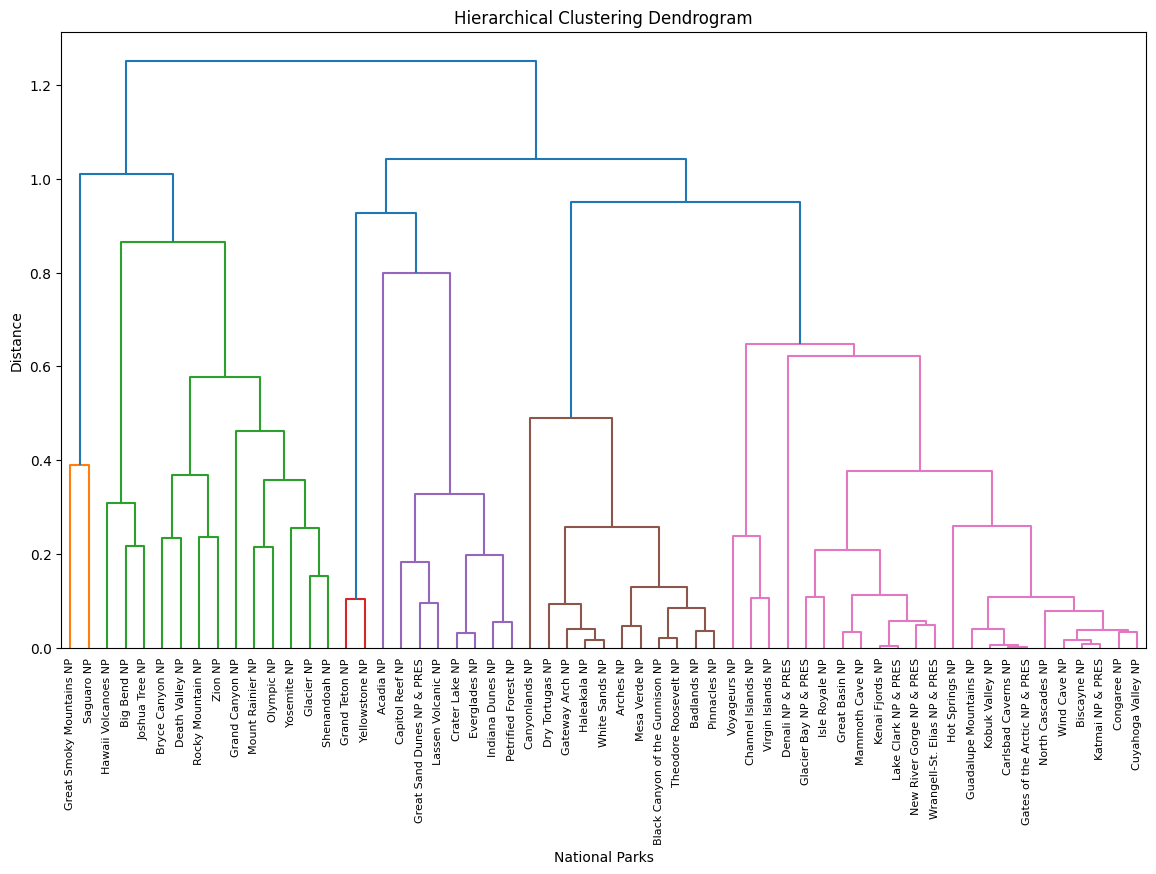

In [87]:
cos = cosine_similarity(x_scaled2)
cos_dist = 1 - cos
condensed_dist = squareform(cos_dist, checks=False)
Z = linkage(condensed_dist, method='average')
plt.figure(figsize=(14,8))
dendrogram(Z,labels=park_agg['Park Name'].values,leaf_rotation=90,leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('National Parks')
plt.ylabel('Distance')

In [ ]:
park_agg['HCluster'] = fcluster(Z,t=4,criterion='maxclust')
park_agg.groupby('HCluster')['Park Name'].apply(list)


HCluster
1               [Great Smoky Mountains NP, Saguaro NP]
2    [Big Bend NP, Bryce Canyon NP, Death Valley NP...
3    [Acadia NP, Capitol Reef NP, Crater Lake NP, E...
4    [Arches NP, Badlands NP, Biscayne NP, Black Ca...
Name: Park Name, dtype: object

The hierarchical clustering dendrogram shows how similar parks are grouped together based on cosine similarity. The parks that get together at lower distances are more similar, meanwhile parks that get together at higher distances are less similar. Yellowstone and Yosemite joined together at a very low distance, meaning that they share many recreation and visitor characteristics. Grand Canyon also joined this group  early suggesting similar patterns of camping, lodging, and recreation activity. Great Smoky Mountains was separate from most other parks until a higher distance meaning that it has a unique profile. This matches the K-Means results, where Great Smoky Mountains formed its own cluster in both the k=3 and k=4 solutions. We can say that the hierarchical clustering results were similar to the K-Means results. Both methods identified major destination parks as being distinct from the majority of parks in the dataset. Based on the major branch separations in the dendrogram 3 to 4 clusters is reasonable, which is consistent with the k=3 and k=4 K-Means solutions.